import sys
!{sys.executable} -m pip install instructor openinference-instrumentation-openai

import sys
!{sys.executable} -m pip install \
    instructor \
    openai \
    arize-phoenix \
    openinference-instrumentation-openai \
    opentelemetry-api \
    opentelemetry-sdk \
    opentelemetry-exporter-otlp \
    tenacity \
    dotenv \
    pydantic

In [1]:
from retrieve_data import retrieve_data
from generate_visualization import Agent
from visualization_from_template import generate_from_template
from init_phoenix import init_phoenix
from utils import execute_code

### Get Tabledata from database and define Query for LLM

Medium-
question = "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis of the data based of total earnings and provide a comprehensive visualization supporting your analysis."

35.3s

samll 
question = "Wieviel Umsatz hatte Teckentrup im Jahr 2021-2024 im Segment JVA? Show a simple bar chart of the total revenue."

42 s

very Large-
question = "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a comprehensive multi-dimensional analysis including: monthly and yearly revenue trends, seasonal patterns, year-over-year growth rates, peak and low performing periods, cumulative totals, and a detailed statistical summary. Support your analysis with multiple visualizations covering trend lines, distribution charts, and comparative breakdowns. Highlight any anomalies or significant changes across the full time period."

1m 5.2s

Large - 
question = "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a comprehensive  a detailed statistical summary. Support your analysis with multiple visualizations covering trend lines, distribution charts, and comparative breakdowns. Highlight any anomalies or significant changes across the full time period."

In [2]:


question = "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis of the data based of total earnings and provide a comprehensive visualization supporting your analysis."

1m 5.6s

In [3]:
query = """
    EVALUATE
    SUMMARIZECOLUMNS(
        Kalender[Jahr],
        Kalender[Monat],  // Include month for detail
        KEEPFILTERS(
            FILTER(
                ALL( Kalender[Jahr] ),
                Kalender[Jahr] >= 2021 && Kalender[Jahr] <= 2024
            )
        ),
        KEEPFILTERS(
            TREATAS(
                {"Justizvollzugsanstalten"},
                Segment[Segment]
            )
        ),
        "Umsatz SD/CO", [Umsatz SD/CO]
    )
    ORDER BY 
        Kalender[Jahr] ASC,
        Kalender[Monat] ASC
"""

In [8]:
md_table =retrieve_data(query, type="test")

### Get OpenAI Agent with API Key

In [9]:
client, tool_calling_client, tracer = init_phoenix()

Overriding of current TracerProvider is not allowed
Attempting to instrument while already instrumented


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: tracing-agent
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [6]:
agent = Agent(client, tool_calling_client, tracer, "o4-mini")

### Send Data
* Question from user
* Context for system

In [10]:
response = agent.start_main_span([{"role": "user", "content": question}, {"role": "system", "content": f"The data is: {md_table}"}])

Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis of the data based of total earnings and provide a comprehensive visualization supporting your analysis.'}, {'role': 'system', 'content': 'The data is: \n        |   Kalender[Jahr] | Kalender[Monat]   |   [Umsatz SD/CO] |\n        |-----------------:|:------------------|-----------------:|\n        |             2021 | Apr               |         30264.05 |\n        |             2021 | Aug               |          9660.99 |\n        |             2021 | Dez               |         31104.06 |\n        |             2021 | Feb               |         11619.17 |\n        |             2021 | Jan               |         12308.10 |\n        |             2021 | Jul               |          4399.77 |\n        |             2021 | Jun               |         12705.90 |\n        |             2021 | Mai               |          

{'titlename': 'Gesamtumsatz pro Jahr', 'charttype': 'line', 'xlabel': 'Jahr', 'ylabel': 'Umsatz (€)', 'y_ticks': (0, 500000, 1000000, 1500000), 'x_ticks': (2021, 2022, 2023, 2024), 'x_tick_label': ('2021', '2022', '2023', '2024'), 'y_tick_label': ('0', '500k', '1M', '1.5M'), 'x_lim': (2020.5, 2024.5), 'y_lim': (0, 1200000), 'annotations': [{'text': '+449% gegenüber 2021', 'target_type': 'point', 'data_id': 1.0, 'data_value': 1124838.0, 'x_value': None, 'y_value': None, 'x_range': None, 'y_range': None, 'style': {'color': 'green', 'fontsize': 10}}, {'text': '−42% gegenüber 2022', 'target_type': 'point', 'data_id': 2.0, 'data_value': 656642.0, 'x_value': None, 'y_value': None, 'x_range': None, 'y_range': None, 'style': {'color': 'red', 'fontsize': 10}}, {'text': '−51% gegenüber 2023', 'target_type': 'point', 'data_id': 3.0, 'data_value': 324925.0, 'x_value': None, 'y_value': None, 'x_range': None, 'y_range': None, 'style': {'color': 'red', 'fontsize': 10}}], 'data': [{'x_data': [2021.0, 

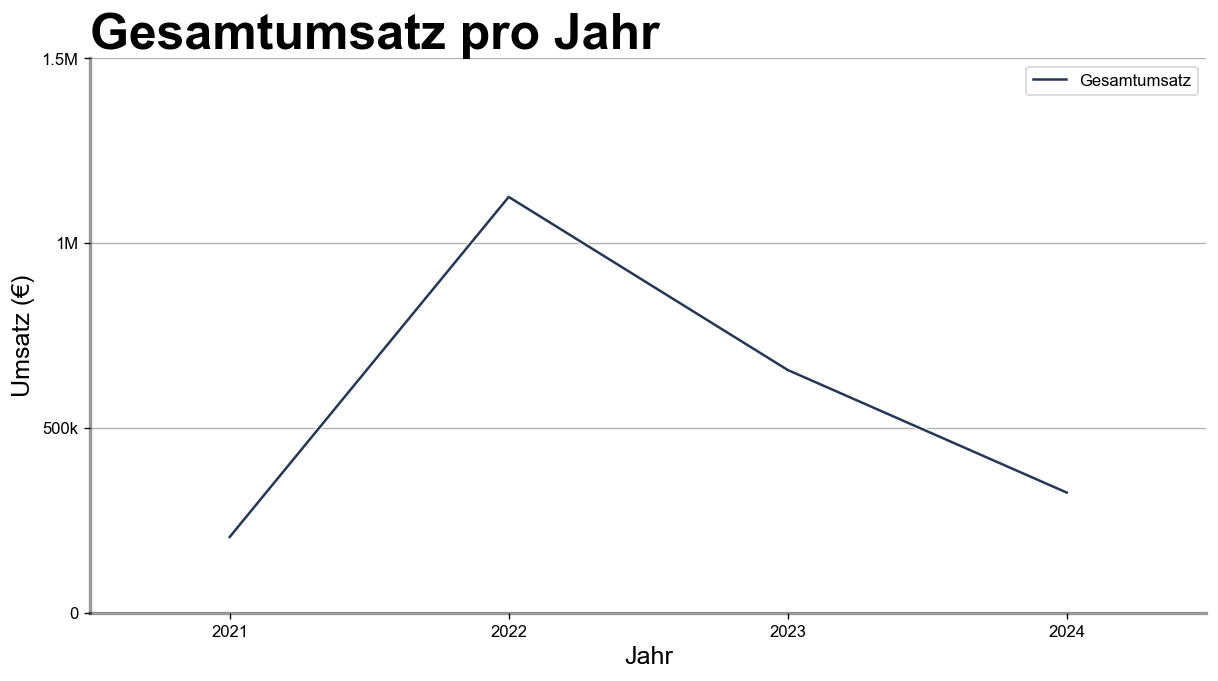

In [11]:
print(response["content"])
generate_from_template(response["content"])

In [12]:
# S5 test — same query you used for S0 baseline
messages = [{
    "role": "user",
    "content": "Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis of the data based on total earnings and provide a comprehensive visualization supporting your analysis."
}]

# Run 3 times
for i in range(1):
    print(f"\n--- S5 Run {i+1} ---")
    result = agent.start_main_span(messages.copy())


--- S5 Run 1 ---
Starting main span with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis of the data based on total earnings and provide a comprehensive visualization supporting your analysis.'}]
Running agent with messages: [{'role': 'user', 'content': 'Wieviel Umsatz hatte Teckentrup in den Jahren 2021 bis 2024 im Segment JVA? Provide a detailed analysis of the data based on total earnings and provide a comprehensive visualization supporting your analysis.'}]
Starting router call span
Making router call to OpenAI
Received response with tool calls: True
Starting tool calls span


KeyboardInterrupt: 

{'titlename': 'Monatlicher Umsatz SD/CO (Jan 2021 - Dez 2024)', 'charttype': 'line', 'xlabel': 'Monat', 'ylabel': 'Umsatz (€)', 'y_ticks': (0, 50000, 100000, 150000, 200000, 250000), 'x_ticks': (0, 6, 12, 18, 24, 30, 36, 42, 47), 'x_tick_label': ('Jan 21', 'Jul 21', 'Jan 22', 'Jul 22', 'Jan 23', 'Jul 23', 'Jan 24', 'Jul 24', 'Dez 24'), 'y_tick_label': ('0', '50k', '100k', '150k', '200k', '250k'), 'x_lim': (0, 47), 'y_lim': (0, 260000), 'annotations': [{'text': 'Maxima: Jun 2022 (242 067 €)', 'target_type': 'point', 'data_id': 17.0, 'data_value': 242067.31, 'x_value': 17.0, 'y_value': 242067.31, 'x_range': None, 'y_range': None, 'style': None}, {'text': 'Niedrigster Umsatz: Sep 2024 (0 €)', 'target_type': 'point', 'data_id': 44.0, 'data_value': 0.0, 'x_value': 44.0, 'y_value': 0.0, 'x_range': None, 'y_range': None, 'style': None}], 'data': [{'x_data': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24

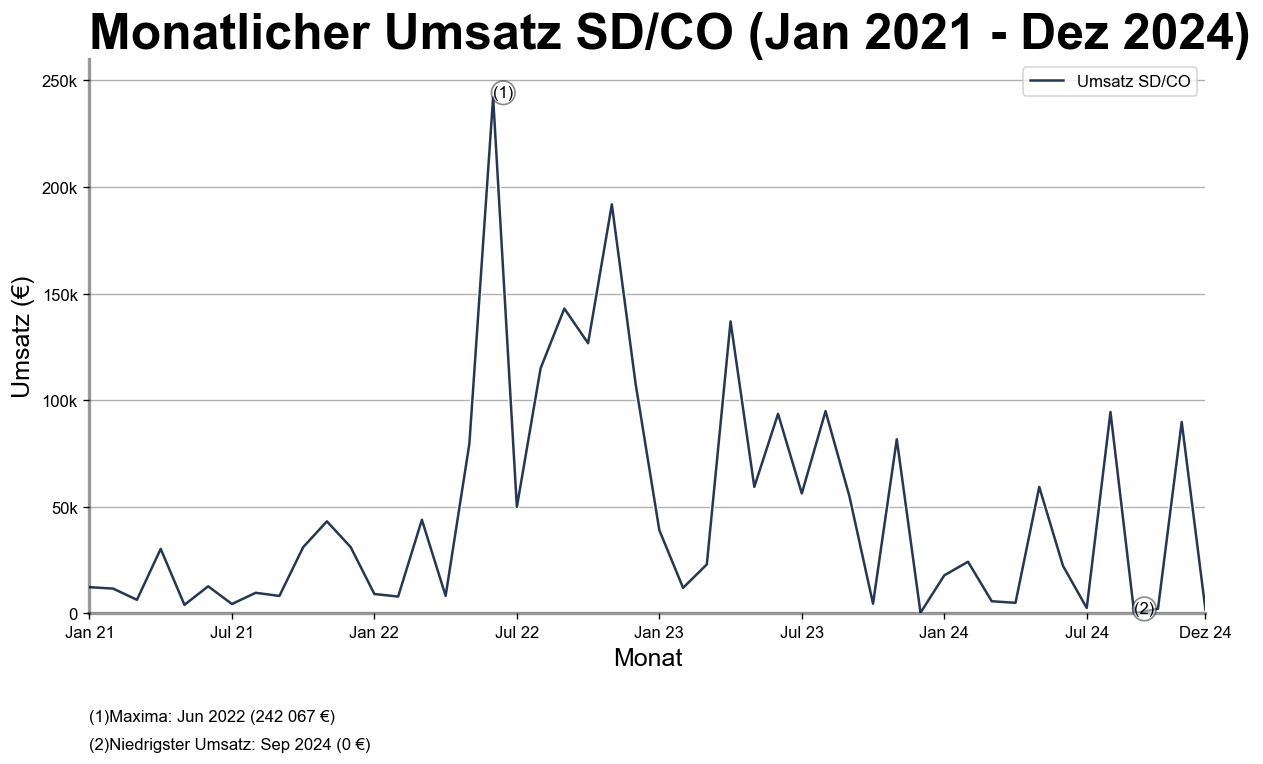

In [ ]:
print(response["content"])
generate_from_template(response["content"])

In [ ]:
import json

### Answer is converted from Dict to JSON and executed

In [ ]:
print(json.dumps(response, indent=4))

{
    "role": "tool",
    "content": {
        "titlename": "Monatlicher Umsatz SD/CO (Jan 2021 - Dez 2024)",
        "charttype": "line",
        "xlabel": "Monat",
        "ylabel": "Umsatz (\u20ac)",
        "y_ticks": [
            0,
            50000,
            100000,
            150000,
            200000,
            250000
        ],
        "x_ticks": [
            0,
            6,
            12,
            18,
            24,
            30,
            36,
            42,
            47
        ],
        "x_tick_label": [
            "Jan 21",
            "Jul 21",
            "Jan 22",
            "Jul 22",
            "Jan 23",
            "Jul 23",
            "Jan 24",
            "Jul 24",
            "Dez 24"
        ],
        "y_tick_label": [
            "0",
            "50k",
            "100k",
            "150k",
            "200k",
            "250k"
        ],
        "x_lim": [
            0,
            47
        ],
        "y_lim": [
            0,

In [ ]:
execute_code(response.code)

AttributeError: 'dict' object has no attribute 'code'

In [ ]:
print(response.analysis)

AttributeError: 'dict' object has no attribute 'analysis'

In [ ]:
print(response.code_config)

AttributeError: 'dict' object has no attribute 'code_config'

In [ ]:
exec(response.code)

AttributeError: 'dict' object has no attribute 'code'